In [ ]:
import pandas as pd
import re
import unicodedata
import numpy as np
import joblib
import torch
import os
from transformers import AutoTokenizer, AutoModel, BertTokenizer, BertModel, AutoModelForSequenceClassification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

In [ ]:
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/BE Project/1. Word Sense Disambiguation/Colab/mini_project/Ambiguous Dataset - Sheet1.tsv"
df_org = pd.read_csv(file_path, sep='\t')
df_org = df_org.sample(frac=1.0, random_state = 42)
df_org.head()

,Category,Marathi,Ambiguous
1411,झाडाचे पान,काही झाडांच्या पानांमध्ये औषधी गुणधर्म असतात.,पान
7555,बाहू,त्याच्या दंडावर एक खोलसर जखम होती.,दंड
4930,आदर,समाजात शिक्षणाला खूप मान आहे.,मान
10054,हुक,घराच्या भिंतीला पडदे लावण्यासाठी दोन मोठे आकडे...,आकडा
2714,एकत्र,वृत्तसंस्थेने विविध स्त्रोतांकडून बातम्या गोळा...,गोळा


In [ ]:
df_org = df_org.drop_duplicates()

In [ ]:
df_org.shape

(17195, 3)

In [ ]:
df_org['cleaned_text'] = df_org['Marathi'].str.replace(r'[^\u0900-\u097F\s]', '', regex=True)
df_org['cleaned_text'] = df_org['cleaned_text'].str.strip()

In [ ]:
def find_target_index(row):
    sentence = row['cleaned_text']
    target = row['Ambiguous'].strip()

    #1: find exact word in the sentence
    words = sentence.split()
    try:
        return words.index(target)
    except ValueError:
        #2: find word as a substring
        for i, word in enumerate(words):
            if target in word:
                return i

        # Option 3: Try with regex to handle potential spacing/character variations
        matches = list(re.finditer(re.escape(target), sentence))
        if matches:
            # Find the character position of the first match
            char_pos = matches[0].start()
            # Count words up to this character position
            words_before = len(sentence[:char_pos].split())
            return words_before

        # If all methods fail, mark as not found
        print(f"Warning: Target word '{target}' not found in sentence: '{sentence}'")
        return -1


In [ ]:
df_org['Target_Index'] = df_org.apply(find_target_index, axis=1)

In [ ]:
print(f"Rows before filtering: {len(df_org)}")

Rows before filtering: 17195


In [ ]:
df_org = df_org[df_org['Target_Index'] >= 0]

In [ ]:
print(f"Rows after filtering: {len(df_org)}")

Rows after filtering: 16774


In [ ]:
labels = df_org['Category'].unique().tolist()
labels = [s.strip() for s in labels]
labels

['झाडाचे पान',
 'बाहू',
 'आदर',
 'एकत्र',
 'जागा',
 'तुटणे',
 'घड्याळ',
 'हुक',
 'किंमत',
 'संख्या',
 'क्रिया',
 'पाठी',
 'चेष्टा',
 'नौका',
 'धरण',
 'खाद्य',
 'फायदे',
 'खिळा',
 'सवय',
 'वळणधारी',
 'कागद',
 'दिवस',
 'बाण',
 'जलमार्ग',
 'उत्तर दिशा',
 'दागिना',
 'धडा',
 'दुमडणे',
 'परिणाम',
 'इमोशन',
 'वाहन',
 'जड',
 'मार्ग',
 'प्रारंभ',
 'गळा',
 'देठ',
 'गोंधळ',
 'पठार',
 'प्रतिसाद',
 'बसणे',
 'लग्नाचा प्रस्ताव',
 'चेंडू',
 'किनारा',
 'पूर्व दिशा',
 'बांधणे',
 'विशेषता',
 'करभर',
 'थांबणे',
 'आक्रमण',
 'लाकडी फळक',
 'अंक',
 'अडचण',
 'ब्लिस्टर',
 'फूलांची माला',
 'भूतकाळ',
 'शिक्षा',
 'निर्माण',
 'नाव']

In [ ]:
len(labels)

58

In [ ]:
for key, value in enumerate(labels):
  print(value)

झाडाचे पान
बाहू
आदर
एकत्र
जागा
तुटणे
घड्याळ
हुक
किंमत
संख्या
क्रिया
पाठी
चेष्टा
नौका
धरण
खाद्य
फायदे
खिळा
सवय
वळणधारी
कागद
दिवस
बाण
जलमार्ग
उत्तर दिशा
दागिना
धडा
दुमडणे
परिणाम
इमोशन
वाहन
जड
मार्ग
प्रारंभ
गळा
देठ
गोंधळ
पठार
प्रतिसाद
बसणे
लग्नाचा प्रस्ताव
चेंडू
किनारा
पूर्व दिशा
बांधणे
विशेषता
करभर
थांबणे
आक्रमण
लाकडी फळक
अंक
अडचण
ब्लिस्टर
फूलांची माला
भूतकाळ
शिक्षा
निर्माण
नाव


In [ ]:
NUM_LABELS = len(labels)
label2id = {label: id for id, label in enumerate(labels)}
id2label = {id: label for id, label in enumerate(labels)}

In [ ]:
label2id

{'झाडाचे पान': 0,
 'बाहू': 1,
 'आदर': 2,
 'एकत्र': 3,
 'जागा': 4,
 'तुटणे': 5,
 'घड्याळ': 6,
 'हुक': 7,
 'किंमत': 8,
 'संख्या': 9,
 'क्रिया': 10,
 'पाठी': 11,
 'चेष्टा': 12,
 'नौका': 13,
 'धरण': 14,
 'खाद्य': 15,
 'फायदे': 16,
 'खिळा': 17,
 'सवय': 18,
 'वळणधारी': 19,
 'कागद': 20,
 'दिवस': 21,
 'बाण': 22,
 'जलमार्ग': 23,
 'उत्तर दिशा': 24,
 'दागिना': 25,
 'धडा': 26,
 'दुमडणे': 27,
 'परिणाम': 28,
 'इमोशन': 29,
 'वाहन': 30,
 'जड': 31,
 'मार्ग': 32,
 'प्रारंभ': 33,
 'गळा': 34,
 'देठ': 35,
 'गोंधळ': 36,
 'पठार': 37,
 'प्रतिसाद': 38,
 'बसणे': 39,
 'लग्नाचा प्रस्ताव': 40,
 'चेंडू': 41,
 'किनारा': 42,
 'पूर्व दिशा': 43,
 'बांधणे': 44,
 'विशेषता': 45,
 'करभर': 46,
 'थांबणे': 47,
 'आक्रमण': 48,
 'लाकडी फळक': 49,
 'अंक': 50,
 'अडचण': 51,
 'ब्लिस्टर': 52,
 'फूलांची माला': 53,
 'भूतकाळ': 54,
 'शिक्षा': 55,
 'निर्माण': 56,
 'नाव': 57}

In [ ]:
df_org['labels'] = df_org.Category.map(lambda x: label2id[x.strip()])
df_org.head()

,Category,Marathi,Ambiguous,cleaned_text,Target_Index,labels
1411,झाडाचे पान,काही झाडांच्या पानांमध्ये औषधी गुणधर्म असतात.,पान,काही झाडांच्या पानांमध्ये औषधी गुणधर्म असतात,2,0
7555,बाहू,त्याच्या दंडावर एक खोलसर जखम होती.,दंड,त्याच्या दंडावर एक खोलसर जखम होती,1,1
4930,आदर,समाजात शिक्षणाला खूप मान आहे.,मान,समाजात शिक्षणाला खूप मान आहे,3,2
2714,एकत्र,वृत्तसंस्थेने विविध स्त्रोतांकडून बातम्या गोळा...,गोळा,वृत्तसंस्थेने विविध स्त्रोतांकडून बातम्या गोळा...,4,3
101,जागा,लहान मुलांसाठी खेळण्याचे स्थळ आवश्यक आहे.,स्थळ,लहान मुलांसाठी खेळण्याचे स्थळ आवश्यक आहे,3,4


In [ ]:
model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

In [ ]:
SPECIAL_START_TOKEN = "[TGT]"
SPECIAL_END_TOKEN = "[/TGT]"
special_tokens = {"additional_special_tokens": [SPECIAL_START_TOKEN, SPECIAL_END_TOKEN]}
tokenizer.add_special_tokens(special_tokens)
def mark_target_word(sentence, target_index):
    if target_index < 0:
        return sentence

    words = sentence.split()
    if target_index >= len(words):
        return sentence

    words[target_index] = f"{SPECIAL_START_TOKEN} {words[target_index]} {SPECIAL_END_TOKEN}"
    return " ".join(words)

In [ ]:
df_org['marked_sentence'] = df_org.apply(
    lambda row: mark_target_word(row['cleaned_text'], row['Target_Index']),
    axis=1
)

In [ ]:
print("\nExamples of marked sentences:")
for i in range(min(5, len(df_org))):
    print(f"Original: {df_org.iloc[i]['cleaned_text']}")
    print(f"Ambiguous: {df_org.iloc[i]['Ambiguous']} (Index: {df_org.iloc[i]['Target_Index']})")
    print(f"Marked: {df_org.iloc[i]['marked_sentence']}")
    print(f"Sense: {df_org.iloc[i]['Category']}")
    print("---")


Examples of marked sentences:
Original: काही झाडांच्या पानांमध्ये औषधी गुणधर्म असतात
Ambiguous: पान  (Index: 2)
Marked: काही झाडांच्या [TGT] पानांमध्ये [/TGT] औषधी गुणधर्म असतात
Sense: झाडाचे पान
---
Original: त्याच्या दंडावर एक खोलसर जखम होती
Ambiguous: दंड  (Index: 1)
Marked: त्याच्या [TGT] दंडावर [/TGT] एक खोलसर जखम होती
Sense: बाहू
---
Original: समाजात शिक्षणाला खूप मान आहे
Ambiguous: मान (Index: 3)
Marked: समाजात शिक्षणाला खूप [TGT] मान [/TGT] आहे
Sense: आदर
---
Original: वृत्तसंस्थेने विविध स्त्रोतांकडून बातम्या गोळा करून संपूर्ण अहवाल तयार केला
Ambiguous: गोळा  (Index: 4)
Marked: वृत्तसंस्थेने विविध स्त्रोतांकडून बातम्या [TGT] गोळा [/TGT] करून संपूर्ण अहवाल तयार केला
Sense: एकत्र
---
Original: लहान मुलांसाठी खेळण्याचे स्थळ आवश्यक आहे
Ambiguous: स्थळ  (Index: 3)
Marked: लहान मुलांसाठी खेळण्याचे [TGT] स्थळ [/TGT] आवश्यक आहे
Sense: जागा
---


In [ ]:
SIZE = df_org.shape[0]
train_df = df_org[:SIZE//2]
val_df = df_org[SIZE//2:(3*SIZE)//4]
test_df = df_org[(3*SIZE)//4:]

In [ ]:
train_texts = list(train_df.marked_sentence)
val_texts = list(val_df.marked_sentence)
test_texts = list(test_df.marked_sentence)

train_labels = list(train_df.labels)
val_labels = list(val_df.labels)
test_labels = list(test_df.labels)

In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
class WSDDataset(Dataset):
    def __init__(self, encodings, labels, target_words=None, sentences=None):
        self.encodings = encodings
        self.labels = labels
        self.target_words = target_words
        self.sentences = sentences

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = WSDDataset(
    train_encodings,
    train_labels,
    train_df.Ambiguous.tolist(),
    train_df.cleaned_text.tolist()
)
val_dataset = WSDDataset(
    val_encodings,
    val_labels,
    val_df.Ambiguous.tolist(),
    val_df.cleaned_text.tolist()
)
test_dataset = WSDDataset(
    test_encodings,
    test_labels,
    test_df.Ambiguous.tolist(),
    test_df.cleaned_text.tolist()
)


In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "ai4bharat/indic-bert",
    num_labels=NUM_LABELS
)

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.resize_token_embeddings(len(tokenizer))
model.config.classifier_dropout = 0.3
model.to(device)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(200002, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertSdpaAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/IndicBERT/Output20',
    do_train=True,
    do_eval=True,
    num_train_epochs=20,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_strategy='epoch',
    logging_dir='/content/drive/MyDrive/IndicBERT/Log20',
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True if cuda.is_available() else False,
    load_best_model_at_end=True
)

In [ ]:
!pip install wandb
import wandb

# Initialize wandb before starting training
wandb.init(project="text_classification", name="finetuning")

eval/accuracy,▁▁▁▃▅▇▇█████████████████████████████████
eval/f1,▁▁▁▄▅▇▇█████████████████████████████████
eval/loss,██▇▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/precision,▁▁▁▂▄▇▇▇████████████████████████████████
eval/recall,▁▁▁▃▄▇▇█████████████████████████████████
eval/runtime,█▁▂▂▂▂▃▁▃▂▂▃▃▂▃▃▂▅▇▅▂▂▄▂▃▃▂▂▂▂▃▂▃▂▂▂▃▂▂▃
eval/samples_per_second,▁█▆▇▆▆▇▆▇▅▅▇▅▆▇▇▆▇▃▂▇▆▇▄▇▇▅▇▇▇▇▅▆▇▇▇▅▇▇▆
eval/steps_per_second,▁█▆▇▆▆▇▆▇▅▅▇▅▆▇▇▆▇▃▂▇▆▇▄▇▇▅▇▇▇▇▅▇▆▇▆▇▅▇▆
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
train/global_step,▁▁▁▁▁▂▂▂▂▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,▂▂▅▃▇▄▂▂▃▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.120100,0.475384,0.901503,0.894201,0.915571,0.898288
2,0.121400,0.370920,0.929406,0.927724,0.933498,0.928700
3,0.082700,0.356107,0.931791,0.930418,0.933935,0.931145
4,0.075800,0.435952,0.925352,0.923196,0.930719,0.924992
5,0.066400,0.436399,0.927737,0.925325,0.933087,0.926979
6,0.061500,0.364476,0.939661,0.938255,0.941730,0.938603
7,0.052300,0.335674,0.945147,0.943063,0.945147,0.943780
8,0.035600,0.371331,0.945147,0.942400,0.946104,0.942351
9,0.029900,0.353297,0.945385,0.943789,0.945555,0.945437
10,0.027300,0.358008,0.948724,0.946418,0.949439,0.946370


TrainOutput(global_step=10500, training_loss=0.03724632719159126, metrics={'train_runtime': 720.1523, 'train_samples_per_second': 232.923, 'train_steps_per_second': 14.58, 'total_flos': 472366213041600.0, 'train_loss': 0.03724632719159126, 'epoch': 20.0})

In [ ]:
model.save_pretrained("/content/drive/MyDrive/IndicBERT/2inp_finetuned,e=20")
tokenizer.save_pretrained("/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20")

('/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20/tokenizer_config.json',
 '/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20/special_tokens_map.json',
 '/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20/spiece.model',
 '/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20/added_tokens.json',
 '/content/drive/MyDrive/IndicBERT/2inp_tokenizer,e=20/tokenizer.json')

In [ ]:
import json
from glob import glob

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import tensorflow as tf

Looking for files in: /content/drive/MyDrive/IndicBERT/Log20
Files found: ['/content/drive/MyDrive/IndicBERT/Log20/events.out.tfevents.1744380589.f697dbbdeb35.349.2']
Found TensorBoard files: ['/content/drive/MyDrive/IndicBERT/Log20/events.out.tfevents.1744380589.f697dbbdeb35.349.2']
Available tags in the event file:
{'images': [], 'audio': [], 'histograms': [], 'scalars': ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/accuracy', 'eval/f1', 'eval/precision', 'eval/recall', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss'], 'distributions': [], 'tensors': ['args/text_summary', 'model_config/text_summary'], 'graph': False, 'meta_graph': False, 'run_metadata': []}
Available scalar tags: ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/accuracy', 'eval/f1', 'ev

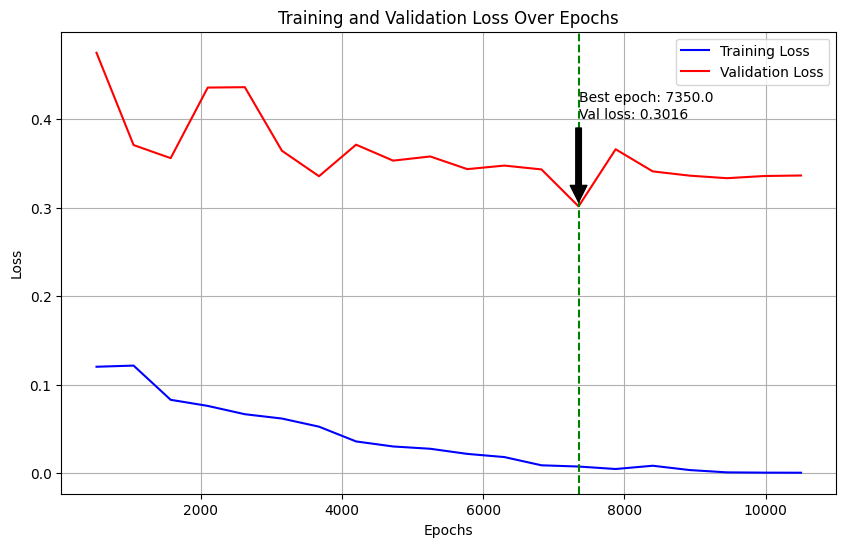

Best epoch: 7350.0 with validation loss: 0.3016


In [ ]:
import json
from glob import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator
import tensorflow as tf

log_dir = '/content/drive/MyDrive/IndicBERT/Log20'

def extract_tensorboard_data(log_dir):
    # Print all available files first to debug
    print("Looking for files in:", log_dir)
    all_files = glob(os.path.join(log_dir, "*"))
    print("Files found:", all_files)

    # Find event files with a more permissive pattern
    event_files = glob(os.path.join(log_dir, "events.*"))

    if not event_files:
        print(f"No TensorBoard event files found in {log_dir}")
        return None, None

    print(f"Found TensorBoard files: {event_files}")

    # Load the event file
    ea = event_accumulator.EventAccumulator(event_files[0])
    ea.Reload()

    # Print available tags to help diagnose
    available_tags = ea.Tags()
    print("Available tags in the event file:")
    print(available_tags)

    if 'scalars' in available_tags:
        print("Available scalar tags:", available_tags['scalars'])

    # Look for appropriate loss metrics among available tags
    train_loss_tag = None
    eval_loss_tag = None

    if 'scalars' in available_tags:
        scalar_tags = available_tags['scalars']

        # Common training loss tags
        train_candidates = ['loss', 'train_loss', 'training/loss', 'train/loss']
        for tag in train_candidates:
            if tag in scalar_tags:
                train_loss_tag = tag
                break

        # Common validation loss tags
        eval_candidates = ['eval_loss', 'validation_loss', 'eval/loss', 'validation/loss', 'val_loss']
        for tag in eval_candidates:
            if tag in scalar_tags:
                eval_loss_tag = tag
                break

    # Extract the loss data if tags were found
    if train_loss_tag and eval_loss_tag:
        train_loss = [(s.step, s.value) for s in ea.Scalars(train_loss_tag)]
        eval_loss = [(s.step, s.value) for s in ea.Scalars(eval_loss_tag)]

        train_df = pd.DataFrame(train_loss, columns=['epoch', 'loss'])
        eval_df = pd.DataFrame(eval_loss, columns=['epoch', 'loss'])

        return train_df, eval_df
    else:
        print(f"Could not find appropriate loss metrics. Available metrics: {scalar_tags if 'scalars' in available_tags else 'None'}")
        return None, None

# Try to extract data
train_df, eval_df = extract_tensorboard_data(log_dir)

# Plot the losses
if train_df is not None and eval_df is not None and not train_df.empty and not eval_df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(train_df['epoch'], train_df['loss'], 'b-', label='Training Loss')
    plt.plot(eval_df['epoch'], eval_df['loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)

    # Find the epoch with minimum validation loss
    min_loss_epoch = eval_df.loc[eval_df['loss'].idxmin()]
    plt.axvline(x=min_loss_epoch['epoch'], color='g', linestyle='--')
    plt.annotate(f'Best epoch: {min_loss_epoch["epoch"]}\nVal loss: {min_loss_epoch["loss"]:.4f}',
                 xy=(min_loss_epoch['epoch'], min_loss_epoch['loss']),
                 xytext=(min_loss_epoch['epoch']+0.5, min_loss_epoch['loss']+0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.savefig('/content/drive/MyDrive/IndicBERT/loss_plot.png')
    plt.show()

    print(f"Best epoch: {min_loss_epoch['epoch']} with validation loss: {min_loss_epoch['loss']:.4f}")
else:
    print("Could not extract log data. Check your log directory and file format.")

In [ ]:
def predict_sense(sentence, target_word):
    words = sentence.split()
    try:
        target_index = words.index(target_word)
    except ValueError:
        target_index = -1
        for i, word in enumerate(words):
            if target_word in word:
                target_index = i
                break

    if target_index >= 0:
        marked_sentence = mark_target_word(sentence, target_index)
    else:
        print(f"Warning: Target word '{target_word}' not found in sentence")
        marked_sentence = sentence

    inputs = tokenizer(marked_sentence, truncation=True, padding="max_length", return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0]
    probabilities = torch.nn.functional.softmax(logits, dim=0)
    predicted_label = torch.argmax(logits).item()
    predicted_sense = id2label[predicted_label]

    top_indices = torch.argsort(probabilities, descending=True)[:3]
    top_predictions = [
        {
            "sense": id2label[idx.item()],
            "confidence": probabilities[idx].item() * 100
        }
        for idx in top_indices
    ]

    return {
        "sentence": sentence,
        "target_word": target_word,
        "target_index": target_index,
        "predicted_sense": predicted_sense,
        "confidence": probabilities[predicted_label].item() * 100,
        "top_predictions": top_predictions
    }


In [ ]:
test_sentence = "गुरूजींनी दिलेला आजचा पाठ इतका विचारप्रवर्तक होता की विद्यार्थ्यांनी केवळ पाठांतर न करता त्यामागील जीवनमूल्यांचाही गांभीर्याने विचार केला."
target_word = "पाठ"
result = predict_sense(test_sentence, target_word)
print(f"Sentence: {result['sentence']}")
print(f"Target word: {result['target_word']} (Index: {result['target_index']})")
print(f"Predicted sense: {result['predicted_sense']} (Confidence: {result['confidence']:.2f}%)")
print("\nTop predictions:")
for pred in result["top_predictions"]:
    print(f"  {pred['sense']}: {pred['confidence']:.2f}%")


NameError: name 'predict_sense' is not defined

In [ ]:
def evaluate_per_word_performance(test_dataset, test_df):
    predictions = trainer.predict(test_dataset)
    pred_labels = predictions.predictions.argmax(-1)
    true_labels = test_df.labels.tolist()

    word_performance = {}

    for i, word in enumerate(test_df.Ambiguous):
        if word not in word_performance:
            word_performance[word] = {
                "total": 0,
                "correct": 0,
                "senses": set()
            }

        word_performance[word]["total"] += 1
        word_performance[word]["senses"].add(test_df.Category.iloc[i])

        if pred_labels[i] == true_labels[i]:
            word_performance[word]["correct"] += 1

    print("\nPer-word disambiguation performance:")
    print("-" * 80)
    print(f"{'Word':<15} {'Accuracy':<10} {'Instances':<10} {'Unique Senses':<15}")
    print("-" * 80)

    for word, stats in sorted(word_performance.items(), key=lambda x: x[1]["total"], reverse=True):
        accuracy = stats["correct"] / stats["total"] * 100
        print(f"{word:<15} {accuracy:.2f}%{'':<5} {stats['total']:<10} {len(stats['senses']):<15}")

    return word_performance

In [ ]:
word_wise_results = evaluate_per_word_performance(test_dataset, test_df)


Per-word disambiguation performance:
--------------------------------------------------------------------------------
Word            Accuracy   Instances  Unique Senses  
--------------------------------------------------------------------------------
माळ             94.09%      237        3              
बांध            96.97%      231        3              
गुण             93.89%      229        3              
वाट             98.58%      211        3              
नाव             89.94%      169        2              
फोड             96.99%      166        2              
उत्तर           98.11%      159        2              
पूर्व           94.87%      156        2              
खोड             98.72%      156        2              
भाव             96.75%      154        2              
पेच             90.07%      151        2              
तीर             97.99%      149        2              
पाट             97.32%      149        2              
मान             94.59%      148

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_test_accuracy(test_dataset, test_df):
    predictions = trainer.predict(test_dataset)
    predicted_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids

    overall_accuracy = accuracy_score(true_labels, predicted_labels)

    print(f"Overall Test Accuracy: {overall_accuracy*100:.2f}%")

    return overall_accuracy

In [ ]:
evaluate_test_accuracy(test_dataset, test_df)

Overall Test Accuracy: 95.59%


0.9558893657606103

1. Dataset improvement.
2. Re-train the model. (indic2input)
3. Finding Sentences other than dataset
4. Comparing the performance of each model (ngram, indic2input, indiclass) on new sentences.
